In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#reading financial loan csv
df=pd.read_csv('/content/financial_loan claned.csv')

In [ ]:
#inspecting first 10 records
df.head(10)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
5,1062608,CA,INDIVIDUAL,3 years,Studio 94 Corp,C,RENT,2021-07-17,2021-03-16,2021-08-12,...,C3,36 months,Not Verified,28000.0,0.1260,275.96,0.1465,8000,11,8637
6,1067441,TX,INDIVIDUAL,10+ years,American Airlines,C,MORTGAGE,2021-11-19,2021-06-14,2021-12-13,...,C2,36 months,Verified,94800.0,0.2453,205.86,0.1427,6000,30,7218
7,1066424,PA,INDIVIDUAL,10+ years,SCI Mahanoy,A,OWN,2021-06-11,2021-07-14,2021-07-14,...,A4,36 months,Verified,59000.0,0.0665,172.10,0.0790,5500,23,6172
8,1065254,FL,INDIVIDUAL,10+ years,Tech Data Corp,A,MORTGAGE,2021-09-02,2021-06-15,2021-10-12,...,A5,36 months,Verified,116400.0,0.0394,762.08,0.0890,24000,31,8650
9,1064589,MI,INDIVIDUAL,10+ years,teltow contracting,B,MORTGAGE,2021-02-09,2021-03-16,2021-03-16,...,B5,60 months,Not Verified,36000.0,0.1773,93.21,0.1269,4125,21,5551


In [ ]:
#inspecting the shape of this dataset
print(f'This financial loan dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

This financial loan dataset contains 38576 rows and 24 columns.


In [ ]:
#checking the basic structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              38571 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

In [ ]:
#checking if there are any duplicate records
print(f'This dataset contains {sum(df.duplicated())} duplicate records.')

This dataset contains 0 duplicate records.


In [ ]:
#inspecting missing data for each column\
df.isna().sum()

,0
id,0
address_state,0
application_type,0
emp_length,0
emp_title,5
grade,0
home_ownership,0
issue_date,0
last_credit_pull_date,0
last_payment_date,0


In [ ]:
#deleting those 5 records where employee title is null
df=df.dropna()

In [ ]:
#inspecting unique values in each column
df_cols=set(df.columns)
exclude=['id','member_id','loan_amount','int_rate']
df_cols=df_cols.difference(exclude)
df_cols=list(df_cols)

for col in df_cols:
  print(f'{col}:\n{df[col].unique()}',end='\n\n')

sub_grade:
['C4' 'E1' 'C5' 'B2' 'A1' 'C3' 'C2' 'A4' 'A5' 'B5' 'B4' 'B3' 'B1' 'D1'
 'A2' 'A3' 'D4' 'D2' 'C1' 'D3' 'E3' 'F1' 'E2' 'E5' 'D5' 'E4' 'F2' 'G3'
 'F3' 'G1' 'F4' 'G4' 'G2' 'F5' 'G5']

term:
[' 60 months' ' 36 months']

verification_status:
['Verified' 'Not Verified']

dti:
[0.01   0.0535 0.2088 ... 0.2721 0.2543 0.272 ]

emp_title:
['Ryder' 'MKC Accounting' 'Chemat Technology Inc' ...
 'Anaheim Regional Medical Center' 'Brooklyn Radiology' 'Allen Edmonds']

home_ownership:
['RENT' 'MORTGAGE' 'OWN' 'OTHER' 'NONE']

address_state:
['GA' 'CA' 'TX' 'IL' 'PA' 'FL' 'MI' 'RI' 'NY' 'MD' 'WI' 'NV' 'UT' 'WA'
 'NH' 'HI' 'MA' 'OK' 'NJ' 'OH' 'AZ' 'CT' 'MN' 'CO' 'TN' 'VA' 'MO' 'DE'
 'NM' 'LA' 'AR' 'KY' 'NC' 'SC' 'WV' 'KS' 'WY' 'OR' 'AL' 'VT' 'MS' 'DC'
 'MT' 'SD' 'AK' 'IN' 'ME' 'ID' 'NE' 'IA']

total_acc:
[ 4 11  9 28 30 23 31 21 33 13  3 15 18 14  8  7 20 39 24 10 19 27  6 16
 45 25  5 43 29 22 41 35 44 36 17 26 37 32 47 52 42 46 12 50 34 59 38 63
 49 48 61 51 55 40 53 62 58 67 54 57 56 70  2

In [ ]:
#replacing 'source verified' with 'verified' in verification status column
df['verification_status'].replace('Source Verified','Verified',inplace=True)

In [ ]:
#rechecking unique values in verification status column
df['verification_status'].unique()

array(['Verified', 'Not Verified'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38571 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38571 non-null  int64  
 1   address_state          38571 non-null  object 
 2   application_type       38571 non-null  object 
 3   emp_length             38571 non-null  object 
 4   emp_title              38571 non-null  object 
 5   grade                  38571 non-null  object 
 6   home_ownership         38571 non-null  object 
 7   issue_date             38571 non-null  object 
 8   last_credit_pull_date  38571 non-null  object 
 9   last_payment_date      38571 non-null  object 
 10  loan_status            38571 non-null  object 
 11  next_payment_date      38571 non-null  object 
 12  member_id              38571 non-null  int64  
 13  purpose                38571 non-null  object 
 14  sub_grade              38571 non-null  object 
 15  term   

In [ ]:
#changing datatypes
df['issue_date']=pd.to_datetime(df['issue_date'],format='%d-%m-%Y')
df['last_credit_pull_date']=pd.to_datetime(df['last_credit_pull_date'],format='%d-%m-%Y')
df['last_payment_date']=pd.to_datetime(df['last_payment_date'],format='%d-%m-%Y')
df['next_payment_date']=pd.to_datetime(df['next_payment_date'],format='%d-%m-%Y')

In [ ]:
#rechecking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38571 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38571 non-null  int64         
 1   address_state          38571 non-null  object        
 2   application_type       38571 non-null  object        
 3   emp_length             38571 non-null  object        
 4   emp_title              38571 non-null  object        
 5   grade                  38571 non-null  object        
 6   home_ownership         38571 non-null  object        
 7   issue_date             38571 non-null  datetime64[ns]
 8   last_credit_pull_date  38571 non-null  datetime64[ns]
 9   last_payment_date      38571 non-null  datetime64[ns]
 10  loan_status            38571 non-null  object        
 11  next_payment_date      38571 non-null  datetime64[ns]
 12  member_id              38571 non-null  int64         
 13  purpos

In [ ]:
#Total number of loan applications
print(f'Total Applications: {df['id'].value_counts().sum()}')

Total Applications: 38571


In [ ]:
#Total Funded Amount
print(f'Total Funded Amount: ${round(df['loan_amount'].sum() / 1000000,2)}M')

Total Funded Amount: $435.69M


In [ ]:
#Total Received Amount
print(f'Total Received Amount: ${round(df['total_payment'].sum() / 1000000,2)}M')

Total Received Amount: $472.99M


In [ ]:
#Average Interest rate
print(f'Avg Interest rate: {round(df['int_rate'].mean()*100,2)}%')

Avg Interest rate: 12.05%


In [ ]:
#Average DTI(Debt to income ratio)
print(f'Average DTI: {round(df['dti'].mean()*100,2)}%')

Average DTI: 13.33%


In [ ]:
#checking loan status for categorisation of good and bad loans
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,32140
Charged Off,5333
Current,1098


In [ ]:
# Good Loan Issued
good_loan_app= df.loc[df['loan_status'].isin(['Current','Fully Paid']),'id'].value_counts().sum()
good_loan_funded_amount= df.loc[df['loan_status'].isin(['Current','Fully Paid']),'loan_amount'].sum()
good_loan_received_amount= df.loc[df['loan_status'].isin(['Current','Fully Paid']),'total_payment'].sum()
print(f'Good Loan Applications: {good_loan_app}')
print(f'Good Loan Funded Amount: ${round(good_loan_funded_amount / 1000000,2)}M')
print(f'Good Loan Received Amount: ${round(good_loan_received_amount / 1000000,2)}M')

Good Loan Applications: 33238
Good Loan Funded Amount: $370.16M
Good Loan Received Amount: $435.71M


In [ ]:
#Bad Loan Issued
bad_loan_app= df.loc[df['loan_status'].isin(['Charged Off']),'id'].value_counts().sum()
bad_loan_funded_amount= df.loc[df['loan_status'].isin(['Charged Off']),'loan_amount'].sum()
bad_loan_received_amount= df.loc[df['loan_status'].isin(['Charged Off']),'total_payment'].sum()
print(f'Bad Loan Applications: {bad_loan_app}')
print(f'Bad Loan Funded Amount: ${round(bad_loan_funded_amount / 1000000,2)}M')
print(f'Bad Loan Received Amount: ${round(bad_loan_received_amount / 1000000,2)}M')

Bad Loan Applications: 5333
Bad Loan Funded Amount: $65.53M
Bad Loan Received Amount: $37.28M


In [ ]:
#setting color palette
sns.set_palette('Blues_d')

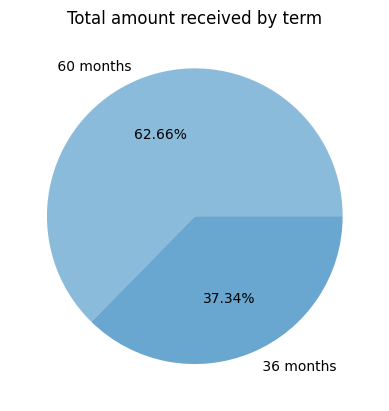

In [ ]:
#Total amount received by term
plt.pie(df['loan_amount'].groupby(df['term']).sum(),labels=df['term'].unique(),autopct='%1.2f%%')
plt.title('Total amount received by term')
plt.show()


In [ ]:
df.to_csv(/content/financial_loan claned.csv)